In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random as rdm
import numpy as np
from scipy.stats import binom, poisson, powerlaw

In [2]:
def distribucion_grado(grados):
    k, conteos = np.unique(grados, return_counts=True)
    pk = conteos / len(grados)
    return k, pk

8,9,1,2

**Ejercicio 1. Comparación de distribuciones**

Genera dos conjuntos de datos de tamaño grande (por ejemplo, $N = 10^4$):

- Uno que siga una distribución de Poisson.
- Otro que siga una distribución de ley de potencia con exponente $\gamma$.

Calcula la distribución de grado $p_k$ en ambos casos.

**Tareas:**

- Grafica ambas distribuciones en escala lineal.
- Grafícalas en escala log-log.
- Compara visualmente ambas gráficas.

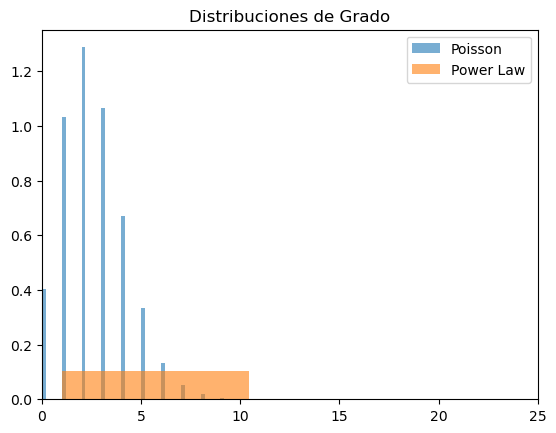

In [3]:
N=10**4; γ=2.5; λ=2.5; n=50
ps = poisson.rvs(λ, size=N)
rng = np.random.default_rng()
k_1,pois =distribucion_grado(ps)
p = rng.zipf(γ, N)
k_2,pow=distribucion_grado(p)
plt.figure()
plt.hist(ps, bins=50, density=True, alpha=0.6, label='Poisson')
plt.hist(p, bins=50, density=True, alpha=0.6, label='Power Law')
plt.xlim(0,25)
plt.legend()
plt.title("Distribuciones de Grado")
plt.show()

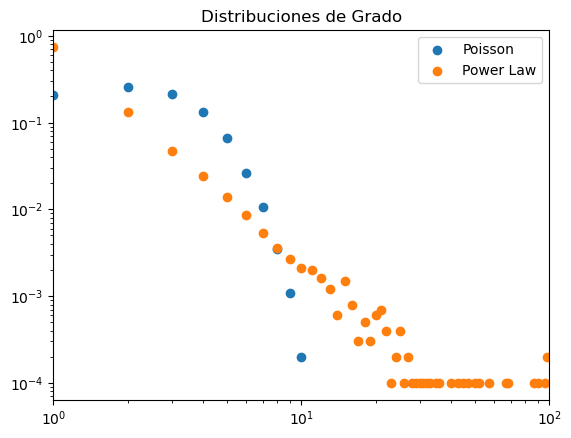

In [4]:
plt.figure()
plt.scatter(k_1,pois,label='Poisson')
plt.scatter(k_2,pow, label='Power Law')
plt.legend()
plt.title("Distribuciones de Grado")
plt.xscale('log')
plt.yscale('log')
plt.xlim(1,10**2)
plt.show()

**Preguntas:**

- ¿Qué diferencias observas entre ambas distribuciones?

La cola de la distribucion es mas pesada en la segunda, existen muchos mas nodos de grado alto.

- ¿En cuál aparecen nodos con grados muy grandes (hubs)?

En la segunda

**Ejercicio 2. Efecto de la escala log-log**

Usando una muestra con distribución de ley de potencia:

**Tareas:**

- Grafica la distribución de grado en escala lineal.
- Grafícala en escala log-log.

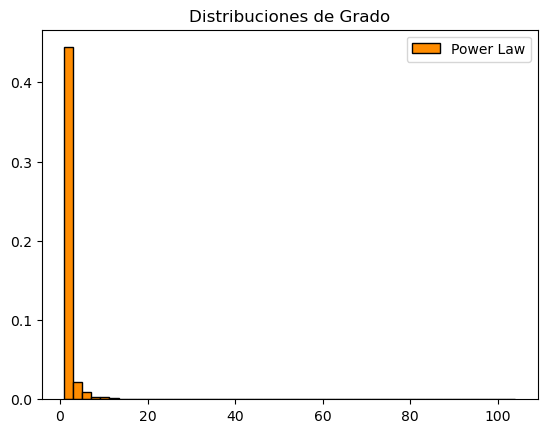

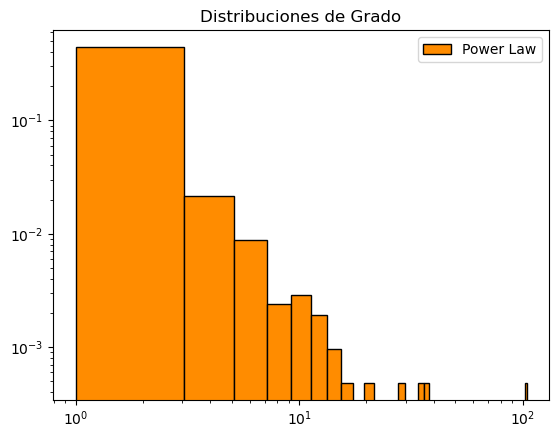

In [5]:
N=10**3; γ=2.5
rng = np.random.default_rng()
pow = rng.zipf(γ, N)
plt.hist(pow, bins=50, density=True, label='Power Law',edgecolor='black',color='darkorange')
plt.legend()
plt.title("Distribuciones de Grado")
plt.show()
plt.hist(pow, bins=50, density=True, label='Power Law',edgecolor='black',color='darkorange')
#plt.xlim(0,25)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.title("Distribuciones de Grado")
plt.show()

**Preguntas:**

- ¿Qué información se pierde en la escala lineal?

Se pierden los detalles en los grados mas altos

- ¿Por qué la gráfica log-log permite observar mejor la cola de la distribución?

Porque deja ver mejor las diferencias entre cantidades pequeñas de observaciones de grados altos.

**Ejercicio 3. Linear binning vs log-binning**

Genera un conjunto de grados con distribución de ley de potencia.

**Tareas:**

- Construye un histograma usando bins lineales.
- Construye un histograma usando bins logarítmicos.
- Grafica ambos en escala log-log.

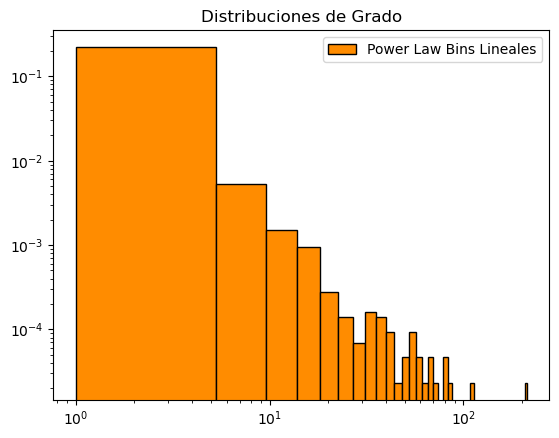

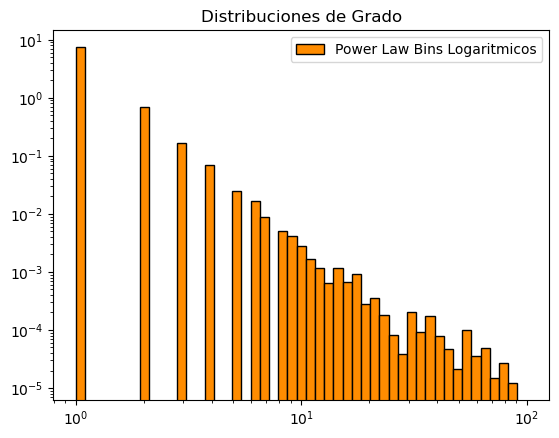

In [6]:
N=10**4; γ=2.5; n=50
rng = np.random.default_rng()
pow = rng.zipf(γ, N)
bsg=np.logspace(0,2,n)
bsl=np.linspace(1,max(pow),n)
plt.hist(pow, bins=bsl, density=True, alpha=1.0, label='Power Law Bins Lineales',edgecolor='black',color='darkorange')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.title("Distribuciones de Grado")
plt.show()
plt.hist(pow, bins=bsg, density=True, alpha=1.0, label='Power Law Bins Logaritmicos',edgecolor='black',color='darkorange',rwidth=1.0)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.title("Distribuciones de Grado")
plt.show()

**Preguntas:**

- ¿Aparece una meseta en la cola con bins lineales?

Si aperece una pequeña meseta

- ¿Qué cambia al usar bins logarítmicos?

Se ve mucho mas lineal

- ¿Cuál método representa mejor la distribución?

Ambas representan la distribucion pero la segunda deja ver mas los detalles al final

**Ejercicio 4. Distribución acumulada**

Dada una muestra de grados con ley de potencia:

**Tareas:**

- Calcula la distribución acumulada complementaria:

  $$P(k) = P(K \geq k)$$

  
- Grafícala en escala log-log.

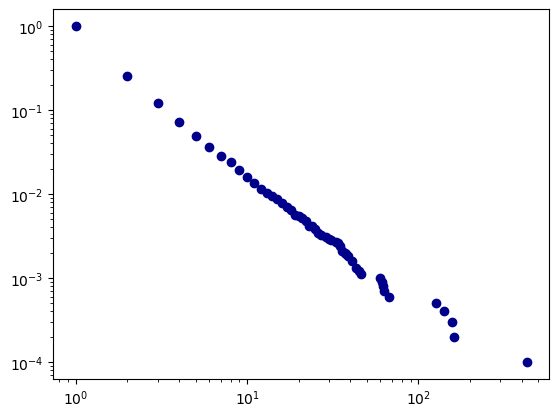

In [7]:
N=10**4; γ=2.5; n=50
rng = np.random.default_rng()
pow = np.sort(rng.zipf(γ, N))
k,p=distribucion_grado(pow)
cp = 1 - np.cumsum(p) + p
plt.scatter(k, cp, color='darkblue')
plt.xscale('log')
plt.yscale('log')

**Preguntas:**

- ¿Qué ventaja tiene la distribución acumulada respecto al histograma?



- ¿Qué sucede con el ruido en la cola?

**Ejercicio 5. El papel del exponente $\gamma$**

Genera distribuciones de ley de potencia con distintos valores de $\gamma$, por ejemplo:

$$\gamma = 2.1, \; 2.5, \; 3.0, \; 4.0$$

**Tareas:**

- Grafica todas las distribuciones en escala log-log.

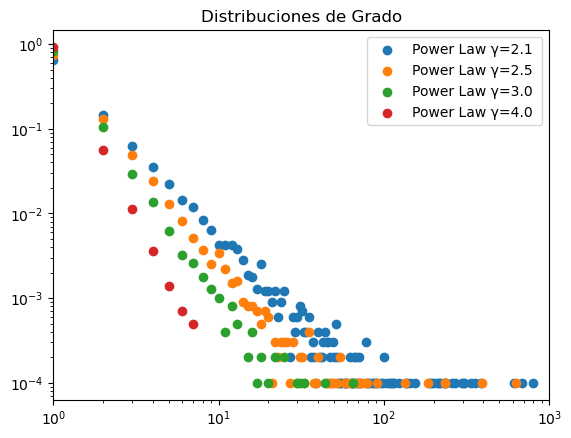

In [8]:
N=10**4; γ=[2.1,2.5,3.0,4.0];
for g in γ:
    rng = np.random.default_rng()
    p = rng.zipf(g, N)
    k,pow=distribucion_grado(p)
    plt.scatter(k,pow, label=fr'Power Law γ={g} ')
    plt.legend()
    plt.title("Distribuciones de Grado")
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(1,10**3)
plt.show()

**Ejercicio 6. Tamaño de la red y hubs**

Para distintos tamaños de red:

$$N = 10^2, 10^3, 10^4, 10^5$$

genera muestras con distribución de ley de potencia.

**Tareas:**

- Para cada $N$, calcula el grado máximo $k_{\max}$.
- Grafica $k_{\max}$ como función de $N$.

In [9]:
N=[10**2,10**3,10**4,10**5]; γ=2.5; k_m=[]
rng = np.random.default_rng()
p = rng.zipf(γ, N[0])
k_m.append(max(p))

In [10]:
p = rng.zipf(γ, N[1])
k_m.append(max(p))

In [11]:
p = rng.zipf(γ, N[2])
k_m.append(max(p))

In [12]:
p = rng.zipf(γ, N[3])
k_m.append(max(p))

In [13]:
k_m

[19, 65, 300, 1274]

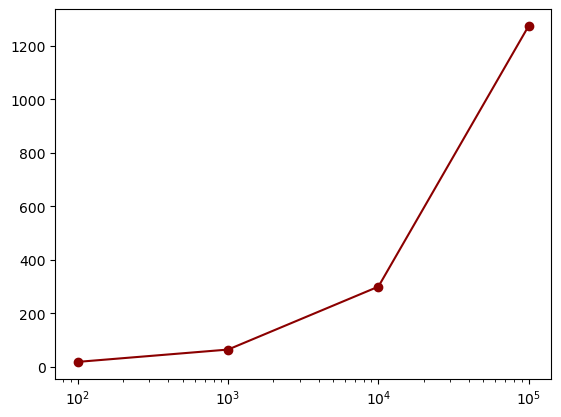

In [14]:
plt.scatter(N,k_m,color='darkred')
plt.plot(N,k_m,color='darkred')
plt.xscale('log')

**Preguntas:**

- ¿Cómo crece el hub más grande con el tamaño de la red?

El hub mas grande explota cuando la red crece.
  
- ¿Es el crecimiento rápido o lento?

Para valores de N peqqueños el crecimiento es lento, pero para N grande es muy rapido.

**Ejercicio 7. Redes aleatorias vs redes libres de escala**

Genera dos redes con el mismo número de nodos:

- Una red de Erdős–Rényi.
- Una red de Barabási–Albert, esto simula la red libre de escala.

**Tareas:**

- Calcula la distribución de grado en ambas redes.
- Grafícalas en escala log-log.
- Calcula:
  - grado promedio
  - grado máximo

In [19]:
N=100; p=0.05; m=2
E= nx.erdos_renyi_graph(N,p)
B= nx.barabasi_albert_graph(N,m)

g_er = [grado for nodo, grado in E.degree()]
g_ba = [grado for nodo, grado in B.degree()]
k_e,de = distribucion_grado(g_er)
k_b,db = distribucion_grado(g_ba)
plt.figure()
plt.scatter(k_e,de, color='darkred',label='Erdos Renyi')
plt.plot(k_e,de, color='darkred')
plt.scatter(k_e,de, color='darkblue',label='Libre de escala')
plt.plot(k_e,de, color='darkblue')